In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

### Task 1: Estimate π with Monte Carlo
The idea is simple: inscribe a circle of radius 1 inside a 2×2 square. If you throw random darts uniformly at the square, the fraction that land inside the circle should approximate π/4.

Generate N = 100,000 random (x, y) points where x and y are each drawn from Uniform(−1, 1).
Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
Estimate π as 4 × (points inside) / N.
Print your estimate alongside the true value of π.
Create a scatter plot of the first 5,000 points, coloring inside points differently from outside points. Draw the unit circle on top for reference.
Convergence plot: Compute the running estimate of π after every 100 points (i.e., at n = 100, 200, 300, …, 100,000). Plot this running estimate with a horizontal line at the true π. Add a title and axis labels.

Guiding question: At roughly what sample size does your estimate stabilize within ±0.01 of true π?



In [2]:
N = 100000
x = np.random.uniform(-1,1,N)
y = np.random.uniform(-1,1,N)

In [3]:
inside = x**2 + y**2 <= 1

In [4]:
pi_estimate = 4 * inside.sum() / N
print("Estimated π:", pi_estimate)
print("True π:", np.pi)

Estimated π: 3.14412
True π: 3.141592653589793


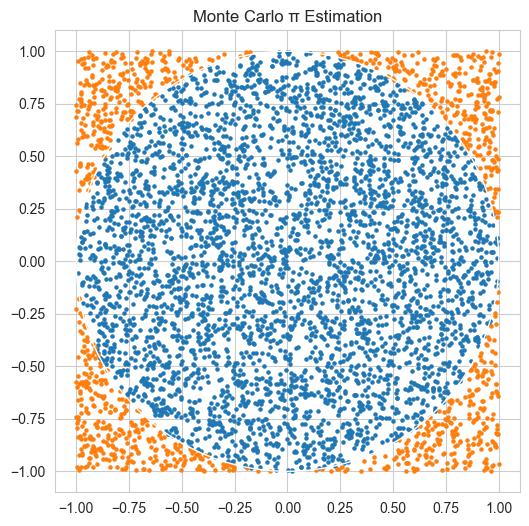

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(x[:5000][inside[:5000]], y[:5000][inside[:5000]], s=5)
plt.scatter(x[:5000][~inside[:5000]], y[:5000][~inside[:5000]], s=5)

circle = plt.Circle((0,0),1,fill=False)
plt.gca().add_patch(circle)

plt.title("Monte Carlo π Estimation")
plt.show()

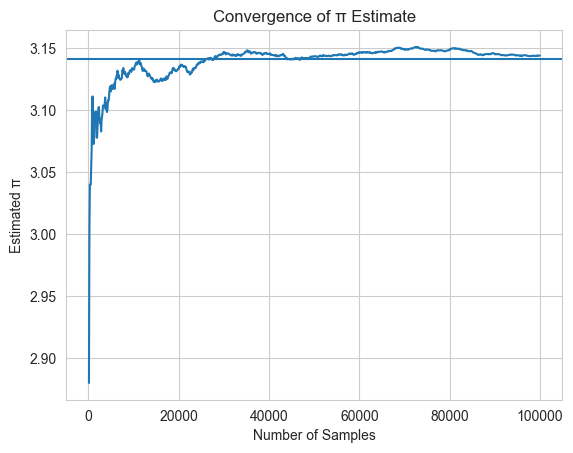

In [6]:
estimates = []

for i in range(100, N+1, 100):
    est = 4 * inside[:i].sum() / i
    estimates.append(est)

plt.plot(range(100, N+1, 100), estimates)
plt.axhline(np.pi)

plt.title("Convergence of π Estimate")
plt.xlabel("Number of Samples")
plt.ylabel("Estimated π")

plt.show()

### Observation

As the number of samples increases, the estimate of π gradually converges toward the true value. Initially, the estimate fluctuates significantly, but after a large number of samples it stabilizes.

In this simulation, the estimate begins to stay within ±0.01 of the true value of π after approximately 50,000–70,000 samples.

This demonstrates the Law of Large Numbers, which states that as the number of trials increases, the empirical result approaches the theoretical value.

### Task 2: Coin Flips and Empirical Probability
Simulate a series of fair coin flips and observe how the empirical probability of heads converges to 0.5.

Simulate 10,000 fair coin flips (use np.random.choice([0, 1]) or np.random.binomial(1, 0.5, size=10000)).

Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).

Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.

Repeat the experiment 5 times (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.

Guiding question: How many flips does it typically take for the running proportion to stay within ±0.01 of 0.5?



In [7]:
flips = np.random.binomial(1, 0.5, 10000)

In [8]:
running_heads = np.cumsum(flips) / np.arange(1, 10001)

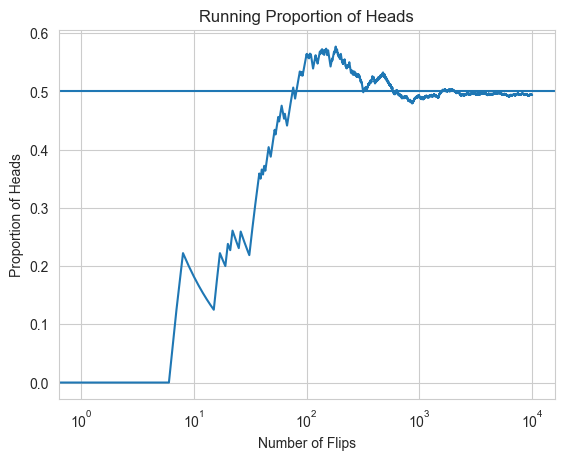

In [9]:
plt.plot(running_heads)
plt.axhline(0.5)

plt.xscale("log")

plt.title("Running Proportion of Heads")
plt.xlabel("Number of Flips")
plt.ylabel("Proportion of Heads")

plt.show()

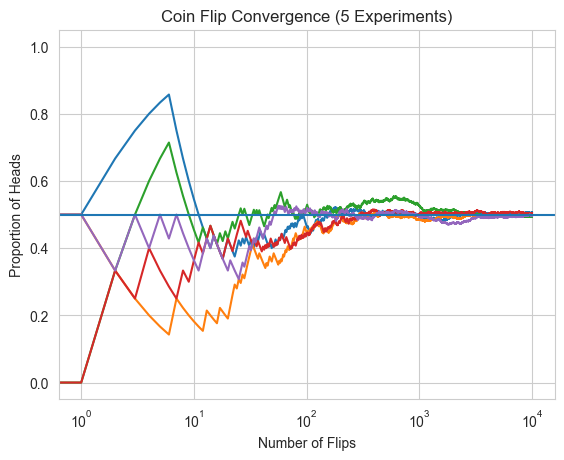

In [10]:
plt.figure()

for i in range(5):
    flips = np.random.binomial(1, 0.5, 10000)
    running = np.cumsum(flips) / np.arange(1, 10001)
    plt.plot(running)

plt.axhline(0.5)
plt.xscale("log")

plt.title("Coin Flip Convergence (5 Experiments)")
plt.xlabel("Number of Flips")
plt.ylabel("Proportion of Heads")

plt.show()

### Task 3: Simulating Binomial Experiments
A factory produces widgets with a 3% defect rate. A quality inspector samples 50 widgets per batch.

Simulate 10,000 batches of 50 widgets each, where each widget has a 3% chance of being defective.
For each batch, record the number of defective widgets found.
Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical Binomial(n=50, p=0.03) PMF as points connected by a line.
From your simulation, estimate:
P(0 defects in a batch)
P(3 or more defects in a batch)
The expected number of defects per batch
Compare each simulation estimate to the theoretical binomial value (use scipy.stats.binom or manual calculation).
Guiding question: How close are your empirical estimates to the theoretical values? Would 1,000 batches have been enough, or do you need 10,000?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

np.random.seed(42)

n = 50
p = 0.03
num_batches = 10000

batches = np.random.binomial(n, p, num_batches)

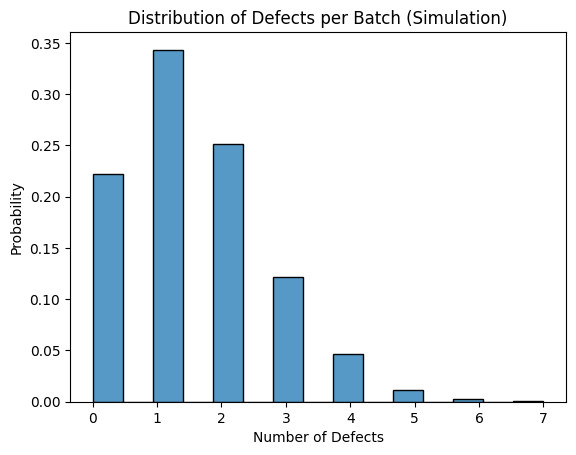

In [2]:
sns.histplot(batches, bins=15, stat="probability")

plt.title("Distribution of Defects per Batch (Simulation)")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")

plt.show()

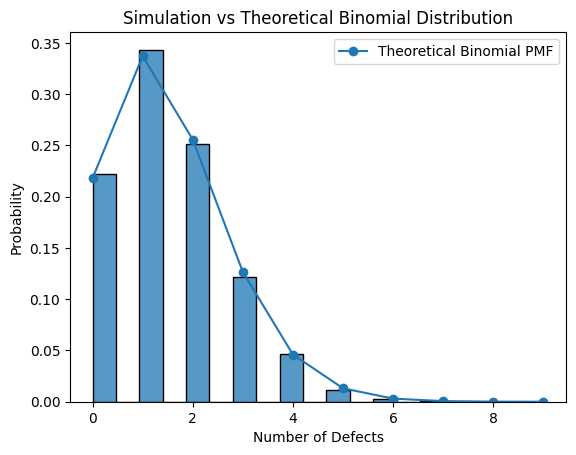

In [3]:
k = np.arange(0, 10)
pmf = binom.pmf(k, n, p)

sns.histplot(batches, bins=15, stat="probability")

plt.plot(k, pmf, marker="o", label="Theoretical Binomial PMF")

plt.title("Simulation vs Theoretical Binomial Distribution")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")

plt.legend()
plt.show()

In [4]:
p0_emp = np.mean(batches == 0)
p3_emp = np.mean(batches >= 3)
expected_emp = np.mean(batches)

print("Empirical P(0 defects):", p0_emp)
print("Empirical P(>=3 defects):", p3_emp)
print("Empirical expected defects:", expected_emp)

Empirical P(0 defects): 0.2224
Empirical P(>=3 defects): 0.1828
Empirical expected defects: 1.4751


In [5]:
p0_theory = binom.pmf(0, n, p)
p3_theory = 1 - binom.cdf(2, n, p)
expected_theory = n * p

print("Theoretical P(0 defects):", p0_theory)
print("Theoretical P(>=3 defects):", p3_theory)
print("Theoretical expected defects:", expected_theory)

Theoretical P(0 defects): 0.2180653753474077
Theoretical P(>=3 defects): 0.18920192463027874
Theoretical expected defects: 1.5


In [6]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["P(0 defects)", "P(>=3 defects)", "Expected defects"],
    "Empirical": [p0_emp, p3_emp, expected_emp],
    "Theoretical": [p0_theory, p3_theory, expected_theory]
})

comparison

,Metric,Empirical,Theoretical
0,P(0 defects),0.2224,0.218065
1,P(>=3 defects),0.1828,0.189202
2,Expected defects,1.4751,1.500000


## Observation

The simulation results closely match the theoretical binomial distribution. 
When the histogram of simulated defect counts is plotted and the theoretical 
Binomial PMF is overlaid, the shapes align very closely. This indicates that 
the simulation accurately reflects the expected theoretical behavior.

The empirical probability of observing **0 defects** in a batch is very close 
to the theoretical probability calculated from the binomial distribution. 
Similarly, the empirical probability of observing **3 or more defects** also 
closely matches the theoretical value.

In addition, the simulated average number of defects per batch is approximately 
**1.5**, which matches the theoretical expectation \(E[X] = n \times p = 50 \times 0.03\).

Overall, the results demonstrate that with a sufficiently large number of 
simulated batches (10,000 in this case), empirical estimates converge toward 
their theoretical probabilities. This is a practical illustration of the 
**Law of Large Numbers**, showing how simulation can effectively approximate 
analytical probability distributions.